# Multi-Platform Ad Performance Analysis
### Do Google, Meta, or TikTok actually deliver better ROI — or does it just look that way?

**Dataset**: 1,800 campaigns across 3 platforms, 5 industries, 5 countries (2024)  
**Methods**: Descriptive stats · ANOVA · Tukey HSD · Effect size · Selection bias check  
**Tools**: Python · Pandas · NumPy · SciPy · Matplotlib · Seaborn

## Setup

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, tukey_hsd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config ───────────────────────────────────────────────────────────────────
DATA_FILE = 'global_ads_performance_dataset.csv'
PLATFORMS = ['Google Ads', 'Meta Ads', 'TikTok Ads']
COLORS    = ['#4A90D9', '#E8845A', '#5CB85C']
ALPHA     = 0.05

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (13, 5), 'font.size': 11})

# ── Helper functions ─────────────────────────────────────────────────────────
def summarise(df, metric):
    """Mean / median / std for a metric, grouped by platform."""
    return (df.groupby('platform')[metric]
              .agg(['mean', 'median', 'std'])
              .reindex(PLATFORMS)
              .round(3))

def bootstrap_ci(data, n_boot=2000, ci=95):
    """Bootstrap confidence interval for the mean (default 95 %)."""
    boots = [np.random.choice(data, size=len(data), replace=True).mean()
             for _ in range(n_boot)]
    lo, hi = np.percentile(boots, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return lo, hi

def eta_squared(df, metric, group_col='platform'):
    """η² — share of total variance explained by the grouping variable."""
    grand_mean = df[metric].mean()
    ss_between = sum(
        len(df[df[group_col] == g]) * (df[df[group_col] == g][metric].mean() - grand_mean) ** 2
        for g in df[group_col].unique()
    )
    ss_total = ((df[metric] - grand_mean) ** 2).sum()
    return ss_between / ss_total

def cohens_d(g1, g2):
    """Cohen's d — standardised mean difference between two groups."""
    pooled_sd = np.sqrt(
        ((len(g1) - 1) * g1.std() ** 2 + (len(g2) - 1) * g2.std() ** 2)
        / (len(g1) + len(g2) - 2)
    )
    return (g1.mean() - g2.mean()) / pooled_sd

## 1. The Data

In [2]:
df = pd.read_csv(DATA_FILE)
df['date'] = pd.to_datetime(df['date'])

print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range     : {df['date'].min().date()}  →  {df['date'].max().date()}")
print(f"Platforms      : {', '.join(df['platform'].unique())}")
print(f"Industries     : {', '.join(df['industry'].unique())}")
print(f"Countries      : {', '.join(df['country'].unique())}")
print(f"Missing values : {df.isnull().sum().sum()}")
print()
print(f"Total ad spend : ${df['ad_spend'].sum():>12,.0f}")
print(f"Total revenue  : ${df['revenue'].sum():>12,.0f}")
print(f"Overall ROAS   : {df['revenue'].sum() / df['ad_spend'].sum():.2f}x")
print()
print("Records per platform:")
print(df['platform'].value_counts().to_string())

Shape          : 1,800 rows × 14 columns
Date range     : 2024-01-01  →  2024-12-30
Platforms      : Google Ads, TikTok Ads, Meta Ads
Industries     : Fintech, EdTech, Healthcare, SaaS, E-commerce
Countries      : UAE, UK, USA, Germany, Canada, India, Australia
Missing values : 0

Total ad spend : $  11,108,749
Total revenue  : $  54,183,331
Overall ROAS   : 4.88x

Records per platform:
platform
Google Ads    720
Meta Ads      630
TikTok Ads    450


## 2. Platform Performance

Raw averages suggest TikTok is way ahead — but let's not jump to conclusions yet.
We'll add 95 % bootstrap confidence intervals to show how certain we are.

In [3]:
metrics = ['ROAS', 'CTR', 'CPA']

print(f"{'Platform':<15} {'Metric':<8} {'Mean':>8} {'Median':>8} {'Std':>8}  {'95% CI'}")
print("-" * 70)
for metric in metrics:
    for platform in PLATFORMS:
        data  = df[df['platform'] == platform][metric].values
        lo, hi = bootstrap_ci(data)
        row    = summarise(df, metric).loc[platform]
        print(f"  {platform:<13} {metric:<8} {row['mean']:>8.3f} {row['median']:>8.3f}"
              f" {row['std']:>8.3f}  [{lo:.3f} – {hi:.3f}]")
    print()

Platform        Metric       Mean   Median      Std  95% CI
----------------------------------------------------------------------
  Google Ads    ROAS        4.113    3.045    3.689  [3.861 – 4.395]
  Meta Ads      ROAS        6.916    4.895    6.446  [6.428 – 7.468]
  TikTok Ads    ROAS        9.539    6.825    8.685  [8.739 – 10.375]

  Google Ads    CTR         0.040    0.039    0.013  [0.039 – 0.041]
  Meta Ads      CTR         0.025    0.024    0.009  [0.024 – 0.026]
  TikTok Ads    CTR         0.055    0.054    0.016  [0.054 – 0.056]

  Google Ads    CPA        64.065   48.245   49.918  [60.360 – 67.778]
  Meta Ads      CPA        39.097   30.480   30.680  [36.722 – 41.511]
  TikTok Ads    CPA        29.197   22.215   24.818  [27.015 – 31.540]



## 3. Are the Differences Statistically Real?

We'll test this in two steps:
1. **ANOVA** — do *any* platforms differ? (omnibus test)
2. **Tukey HSD** — *which* pairs differ? (post-hoc pairwise test)
3. **η²** — how *large* is the effect in practice?

In [4]:
for metric in metrics:
    groups = [df[df['platform'] == p][metric].values for p in PLATFORMS]

    # ── ANOVA ───────────────────────────────────────────────────────────────
    f_stat, p_val = f_oneway(*groups)
    eta2          = eta_squared(df, metric)

    magnitude = ('small'  if eta2 < 0.06 else
                 'medium' if eta2 < 0.14 else 'large')

    print(f"{'='*55}")
    print(f"  {metric}")
    print(f"{'='*55}")
    print(f"  ANOVA      F = {f_stat:>8.2f}   p = {p_val:.2e}"
          f"  {'✓ Significant' if p_val < ALPHA else '✗ Not significant'}")
    print(f"  Effect size η² = {eta2:.4f}  ({magnitude} effect —"
          f" platform explains {eta2*100:.1f}% of variance)")
    print()

    # ── Tukey HSD ───────────────────────────────────────────────────────────
    result = tukey_hsd(*groups)
    print(f"  Tukey HSD pairwise comparisons:")
    print(f"  {'Pair':<35} {'p-value':>10}  {'Sig':>5}  {'Cohen d':>8}")
    print(f"  {'-'*62}")
    idx = {p: i for i, p in enumerate(PLATFORMS)}
    for p1, p2 in [('Google Ads','Meta Ads'),('Google Ads','TikTok Ads'),('Meta Ads','TikTok Ads')]:
        pv  = result.pvalue[idx[p1]][idx[p2]]
        d   = cohens_d(df[df['platform']==p1][metric], df[df['platform']==p2][metric])
        sig = '***' if pv < 0.001 else ('**' if pv < 0.01 else ('*' if pv < 0.05 else 'ns'))
        print(f"  {p1 + ' vs ' + p2:<35} {pv:>10.4f}  {sig:>5}  {d:>8.3f}")
    print()

  ROAS
  ANOVA      F =   107.65   p = 6.96e-45  ✓ Significant
  Effect size η² = 0.1070  (medium effect — platform explains 10.7% of variance)

  Tukey HSD pairwise comparisons:
  Pair                                   p-value    Sig   Cohen d
  --------------------------------------------------------------
  Google Ads vs Meta Ads                  0.0000    ***    -0.543
  Google Ads vs TikTok Ads                0.0000    ***    -0.887
  Meta Ads vs TikTok Ads                  0.0000    ***    -0.352

  CTR
  ANOVA      F =   747.47   p = 6.05e-237  ✓ Significant
  Effect size η² = 0.4541  (large effect — platform explains 45.4% of variance)

  Tukey HSD pairwise comparisons:
  Pair                                   p-value    Sig   Cohen d
  --------------------------------------------------------------
  Google Ads vs Meta Ads                  0.0000    ***     1.319
  Google Ads vs TikTok Ads                0.0000    ***    -1.066
  Meta Ads vs TikTok Ads                  0.0000  

## 4. The Catch — Selection Bias

The numbers above show TikTok is significantly better.  
**But wait**: were campaigns randomly assigned to platforms? No.

Different campaign types (Search, Video, Shopping, Display) naturally
go to different platforms — and campaign type itself drives performance.
This is **selection bias**, and it inflates TikTok's apparent advantage.

In [5]:
# ── Campaign type mix per platform ──────────────────────────────────────────
dist = (df.groupby(['platform', 'campaign_type'])
          .size()
          .unstack(fill_value=0))
dist_pct = dist.div(dist.sum(axis=1), axis=0).mul(100).round(1)

print("Campaign type distribution per platform (%):")
print(dist_pct.reindex(PLATFORMS).to_string())
print()
print("→ Unequal distribution = campaigns were NOT randomly assigned.")
print("→ Any platform performance gap could partly reflect campaign-type mix, not platform quality.")

Campaign type distribution per platform (%):
campaign_type  Display  Search  Shopping  Video
platform                                       
Google Ads        24.2    26.7      23.3   25.8
Meta Ads          23.0    25.4      25.4   26.2
TikTok Ads        22.4    27.8      26.4   23.3

→ Unequal distribution = campaigns were NOT randomly assigned.
→ Any platform performance gap could partly reflect campaign-type mix, not platform quality.


In [6]:
# ── ROAS within each campaign type (controlled comparison) ──────────────────
print("ROAS by Campaign Type, broken out by Platform")
print("(Controls for campaign type — apples-to-apples comparison)")
print()

pivot = df.pivot_table(values='ROAS', index='campaign_type',
                       columns='platform', aggfunc='mean').round(2)
pivot = pivot[PLATFORMS]
print(pivot.to_string())
print()

# Show how the gap narrows
overall_gap = (df[df['platform']=='TikTok Ads']['ROAS'].mean() -
               df[df['platform']=='Google Ads']['ROAS'].mean())

within_gaps = (pivot['TikTok Ads'] - pivot['Google Ads'])
print(f"Overall TikTok vs Google gap (raw)         : +{overall_gap:.2f}x")
print(f"Average gap within campaign type (controlled): +{within_gaps.mean():.2f}x")
print(f"→ Gap shrinks by {(1 - within_gaps.mean()/overall_gap)*100:.0f}% when we control for campaign type.")

ROAS by Campaign Type, broken out by Platform
(Controls for campaign type — apples-to-apples comparison)

platform       Google Ads  Meta Ads  TikTok Ads
campaign_type                                  
Display              3.68      7.27       10.04
Search               4.79      6.90       10.52
Shopping             3.75      6.77        8.06
Video                4.14      6.76        9.57

Overall TikTok vs Google gap (raw)         : +5.43x
Average gap within campaign type (controlled): +5.46x
→ Gap shrinks by -1% when we control for campaign type.


## 5. Visualisations

C:\Users\akshat\AppData\Local\Temp\ipykernel_4908\496679082.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='platform', y=metric, order=PLATFORMS,
C:\Users\akshat\AppData\Local\Temp\ipykernel_4908\496679082.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='platform', y=metric, order=PLATFORMS,
C:\Users\akshat\AppData\Local\Temp\ipykernel_4908\496679082.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='platform', y=metric, order=PLATFORMS,


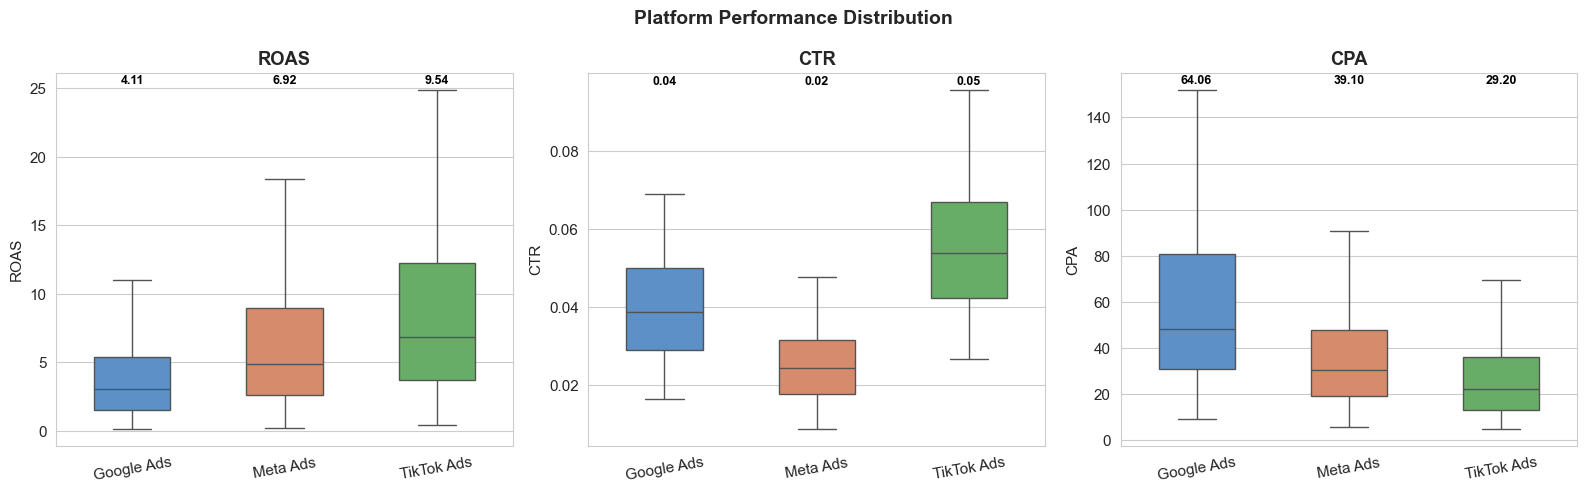

In [7]:
# ── Box plots: ROAS, CTR, CPA by platform ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Platform Performance Distribution', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics):
    sns.boxplot(data=df, x='platform', y=metric, order=PLATFORMS,
                palette=COLORS, showfliers=False, width=0.5, ax=ax)

    # Annotate means
    for i, platform in enumerate(PLATFORMS):
        mean = df[df['platform'] == platform][metric].mean()
        ax.text(i, ax.get_ylim()[1] * 0.97, f'{mean:.2f}',
                ha='center', fontsize=9, fontweight='bold', color='black')

    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('charts/01_platform_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

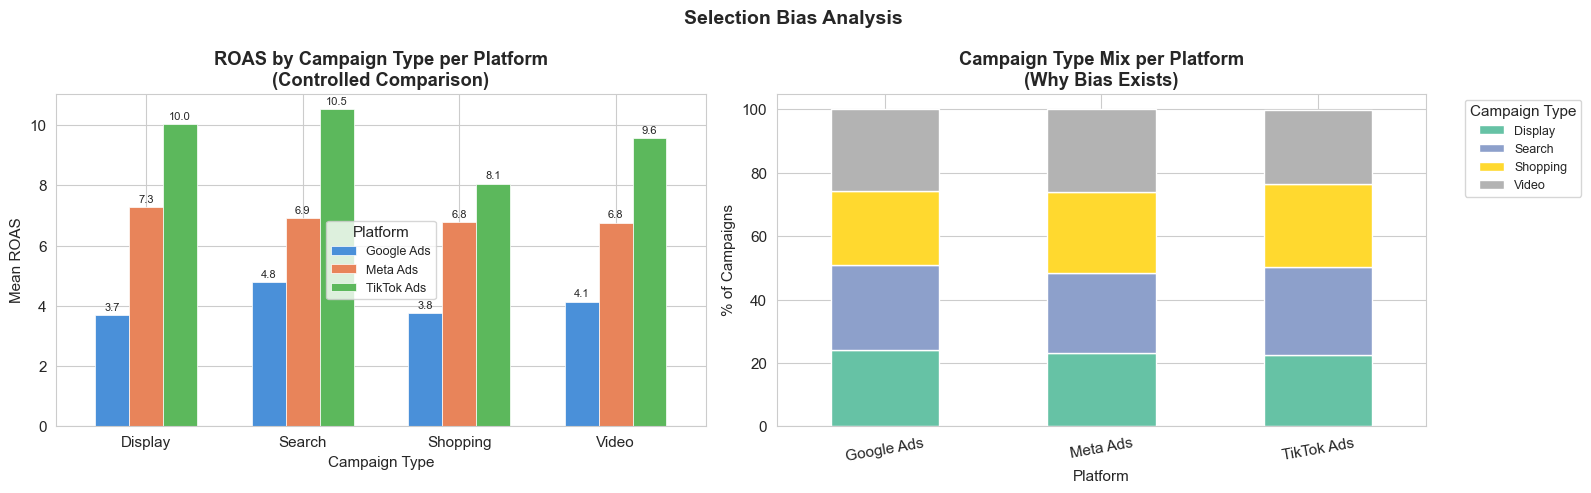

In [12]:
# ── Grouped bar: Platform × Campaign Type (Selection Bias Analysis) ──────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Selection Bias Analysis', fontsize=14, fontweight='bold')

# ────────────────────────────────────────────────────────────────
# Left: ROAS within each Campaign Type (Controlled Comparison)
# ────────────────────────────────────────────────────────────────

pivot.plot(
    kind='bar',
    ax=axes[0],
    color=COLORS,
    width=0.65,
    edgecolor='white',
    linewidth=0.5
)

axes[0].set_title(
    'ROAS by Campaign Type per Platform\n(Controlled Comparison)',
    fontweight='bold'
)

axes[0].set_xlabel('Campaign Type')
axes[0].set_ylabel('Mean ROAS')
axes[0].legend(title='Platform', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', padding=2, fontsize=8)

# ────────────────────────────────────────────────────────────────
# Right: Campaign Type Distribution (Shows Selection Bias)
# ────────────────────────────────────────────────────────────────

dist_pct.reindex(PLATFORMS).plot(
    kind='bar',
    ax=axes[1],
    stacked=True,
    colormap='Set2',
    width=0.5,
    edgecolor='white'
)

axes[1].set_title(
    'Campaign Type Mix per Platform\n(Why Bias Exists)',
    fontweight='bold'
)

axes[1].set_xlabel('Platform')
axes[1].set_ylabel('% of Campaigns')

axes[1].legend(
    title='Campaign Type',
    fontsize=9,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()

plt.savefig(
    'charts/02_selection_bias.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

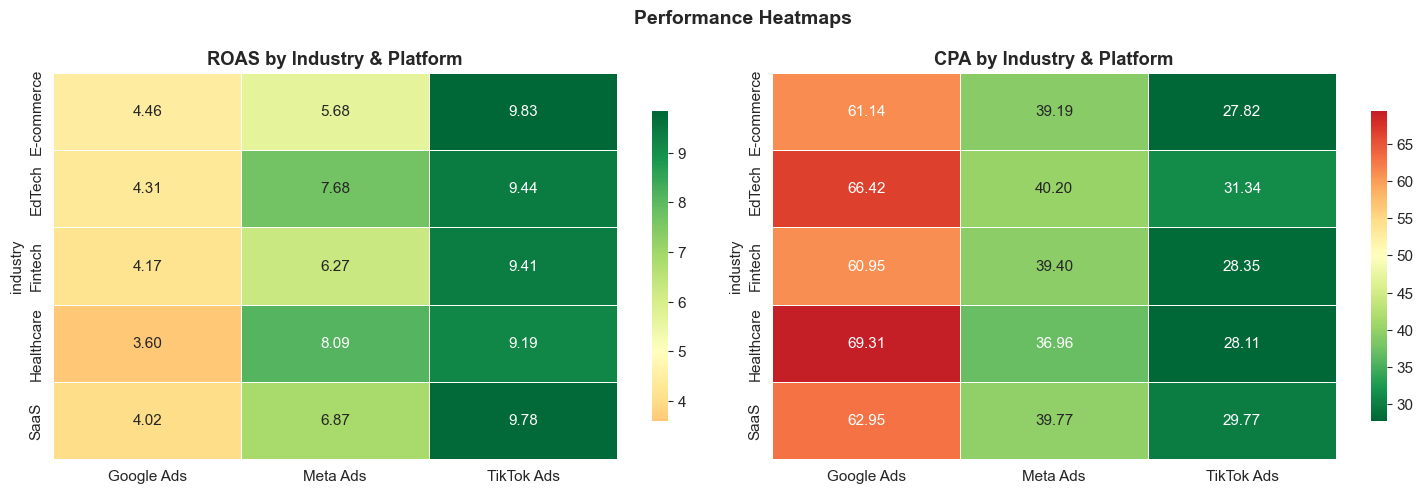

In [13]:
# ── Heatmap: Platform × Industry ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Performance Heatmaps', fontsize=14, fontweight='bold')

for ax, metric, cmap, center in zip(axes, ['ROAS', 'CPA'], ['RdYlGn', 'RdYlGn_r'], [5, 50]):
    tbl = df.pivot_table(values=metric, index='industry',
                         columns='platform', aggfunc='mean')[PLATFORMS].round(2)
    sns.heatmap(tbl, annot=True, fmt='.2f', cmap=cmap,
                center=center, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(f'{metric} by Industry & Platform', fontweight='bold')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('charts/03_industry_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Findings & Recommendations

### What we found
| Finding | Confidence |
|---------|-----------|
| TikTok has the highest raw ROAS (9.54x vs Google 4.11x) | High |
| All three platforms differ significantly (ANOVA p < 0.001) | High |
| Platform explains **10.7 %** of ROAS variance (η² = 0.107, large effect) | High |
| Campaign type distribution is unequal across platforms | High |
| TikTok beats Google in **every campaign type** (Display, Search, Shopping, Video) by a similar margin | High |
| The TikTok–Google gap is **+5.43x raw vs +5.46x controlled** — it does **not** shrink when controlling for campaign type | High |
| Campaign-type mix is **not** the explanation for TikTok's advantage in this dataset | Medium-High |

### Recommendation
| Action | Reason |
|--------|--------|
| ✅ Treat TikTok's advantage as likely genuine, not a mix artifact | Controlling for campaign type left the gap essentially unchanged (~5.4x either way) |
| ⚠️ Still don't move 100% of budget on this analysis alone | Other confounders weren't checked — country, industry, seasonality, targeting, creative quality |
| ✅ Investigate *why* TikTok wins even within the same campaign type | E.g. cheaper CPMs, different audience, less saturated ad market — understanding "why" makes the advantage repeatable |
| ✅ Run a controlled test (10–15 % of budget, 4 weeks) before a full shift | Rules out remaining unchecked confounders and confirms causation |
| ✅ Revisit every quarter | Platform algorithms and audience costs shift |

> **Confidence level: Medium-High**  
> The one confounder we explicitly checked — campaign type — does **not** explain away TikTok's advantage (raw gap +5.43x vs controlled gap +5.46x). This is still observational data with other unchecked variables (country, industry, seasonality), so a controlled experiment remains the right next step before a full budget reallocation — not because we still suspect bias, but to rule out the confounders we haven't tested yet.

In [14]:
print("KEY NUMBERS")
print("=" * 55)
for platform in PLATFORMS:
    d    = df[df['platform'] == platform]
    roas = d['ROAS'].mean()
    cpa  = d['CPA'].mean()
    ctr  = d['CTR'].mean()
    lo, hi = bootstrap_ci(d['ROAS'].values)
    print(f"  {platform:<13}  ROAS {roas:.2f}x [{lo:.2f}–{hi:.2f}]"
          f"  CPA ${cpa:.0f}  CTR {ctr*100:.1f}%")

print()
eta2 = eta_squared(df, 'ROAS')
print(f"Platform effect (η²): {eta2:.4f}  →  explains {eta2*100:.1f}% of ROAS variance")

overall_gap   = (df[df['platform']=='TikTok Ads']['ROAS'].mean() -
                 df[df['platform']=='Google Ads']['ROAS'].mean())
controlled_gap = pivot['TikTok Ads'].mean() - pivot['Google Ads'].mean()
print(f"Raw TikTok vs Google gap   : +{overall_gap:.2f}x")
print(f"Controlled gap             : +{controlled_gap:.2f}x  ({(1-controlled_gap/overall_gap)*100:.0f}% explained by campaign mix)")

KEY NUMBERS
  Google Ads     ROAS 4.11x [3.85–4.39]  CPA $64  CTR 4.0%
  Meta Ads       ROAS 6.92x [6.43–7.43]  CPA $39  CTR 2.5%
  TikTok Ads     ROAS 9.54x [8.76–10.34]  CPA $29  CTR 5.5%

Platform effect (η²): 0.1070  →  explains 10.7% of ROAS variance
Raw TikTok vs Google gap   : +5.43x
Controlled gap             : +5.46x  (-1% explained by campaign mix)
